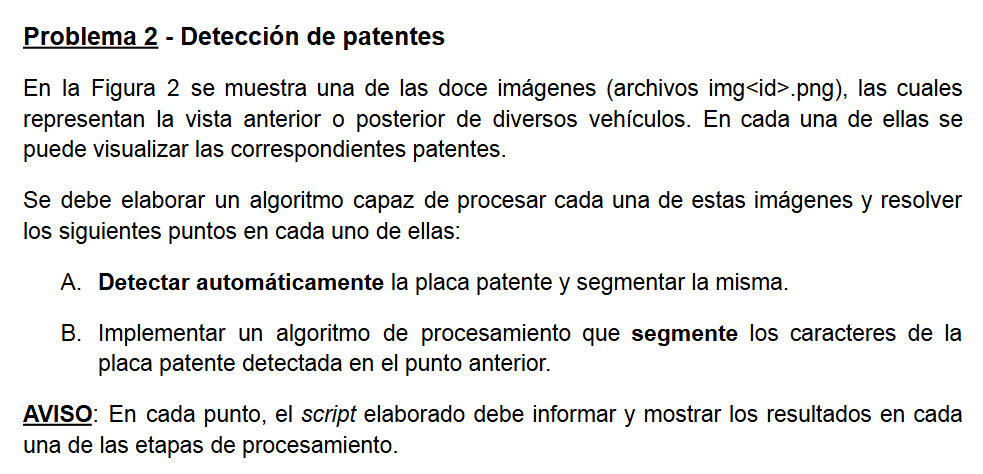

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def mostrar(titulo, imagen, cmap='gray'):
    plt.figure(figsize=(10, 6))
    plt.title(titulo)
    if len(imagen.shape) == 3:
        plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(imagen, cmap=cmap)
    plt.axis('off')
    plt.show()

In [5]:
def detectar_patente_por_componentes(ruta_imagen):    
    img = cv2.imread(ruta_imagen)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h_img, w_img = gray.shape
    
    # binarizacion y canny
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    thresh = cv2.adaptiveThreshold(blur, 255, 
                                   cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 19, 9)
    
    mostrar("Binarización", thresh)

    #filtrar componentes conectadas
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    mask_caracteres = np.zeros_like(gray)
    
    candidatos = 0
    
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(h) / w  # Alto sobre ancho
        area = w * h
        
        keep_aspect = 1.0 < aspect_ratio < 4.0
        
        keep_size = (h_img * 0.02) < h < (h_img * 0.2) and area > 80
        
        if keep_aspect and keep_size:
            cv2.drawContours(mask_caracteres, [cnt], -1, (255), thickness=cv2.FILLED)
            candidatos += 1
            
    mostrar(f"Mascara, candidatos: ({candidatos} encontrados)", mask_caracteres)

    #agrupar
    kernel_fusion = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))
    mask_agrupada = cv2.dilate(mask_caracteres, kernel_fusion, iterations=1)
    
    mostrar("Agrupado", mask_agrupada)
    
    contours_bloques, _ = cv2.findContours(mask_agrupada, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    mejor_rect = None
    max_score = 0
    
    for cnt in contours_bloques:
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(w) / h
        area = w * h
        
        #filtro final patente
        if 2.0 < aspect_ratio < 6.0 and area > 1000:
            if area > max_score:
                max_score = area
                mejor_rect = (x, y, w, h)

    
    px, py, pw, ph = mejor_rect
    
    pad = 5
    px = max(0, px - pad)
    py = max(0, py - pad)
    pw = min(w_img - px, pw + 2*pad)
    ph = min(h_img - py, ph + 2*pad)
    
    roi_patente = img[py:py+ph, px:px+pw]
    mostrar("Patente Detectada", roi_patente)
    
    img_final = img.copy()
    cv2.rectangle(img_final, (px, py), (px+pw, py+ph), (0, 255, 0), 3)
    mostrar(" Resultado Final", img_final)

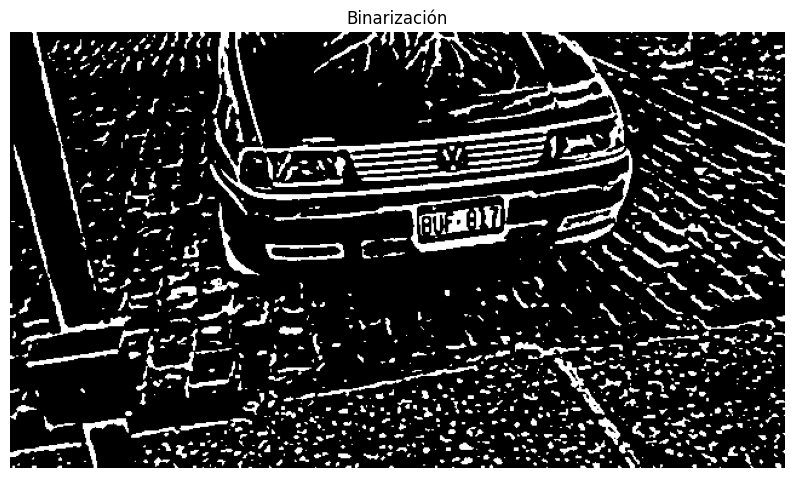

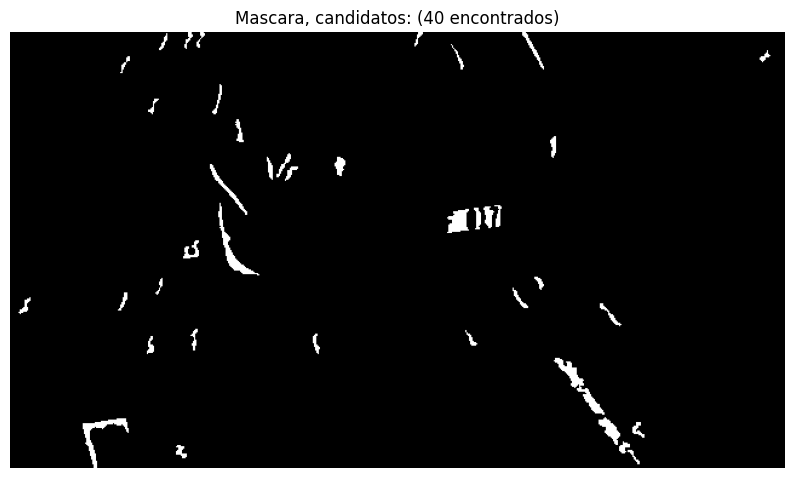

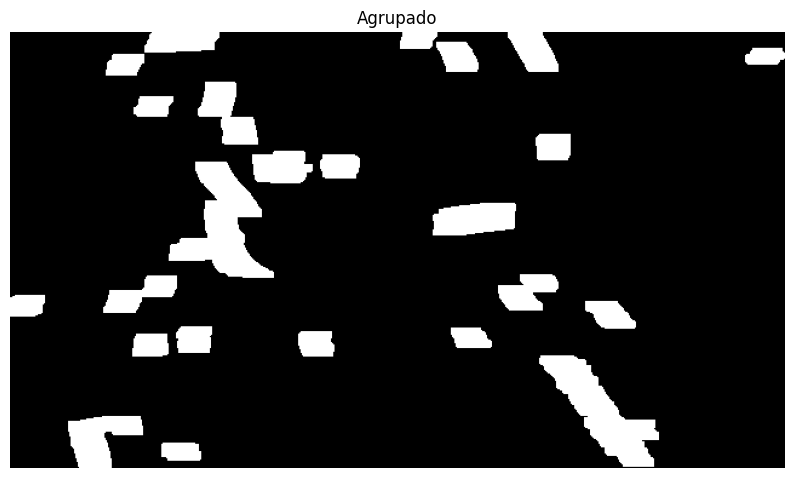

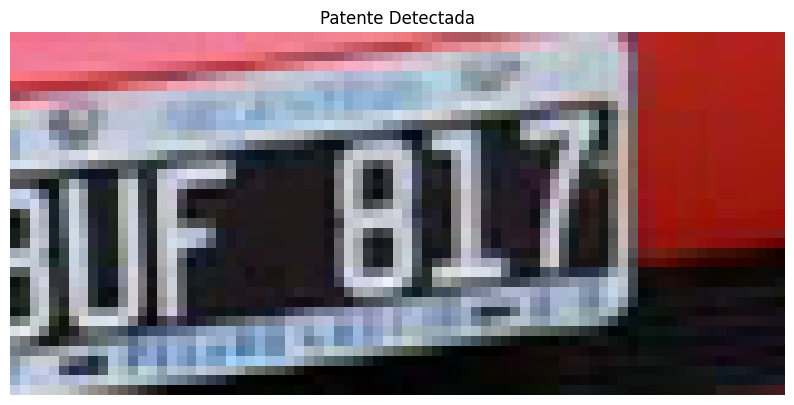

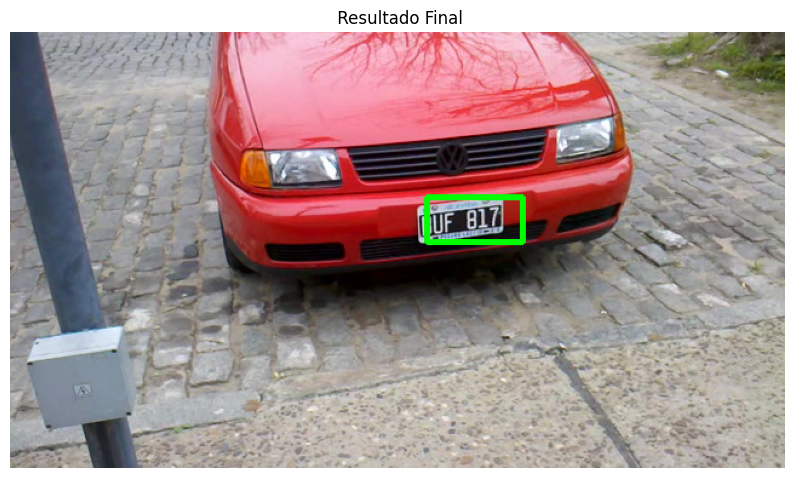

In [ ]:
detectar_patente_por_componentes('img/img01.png')

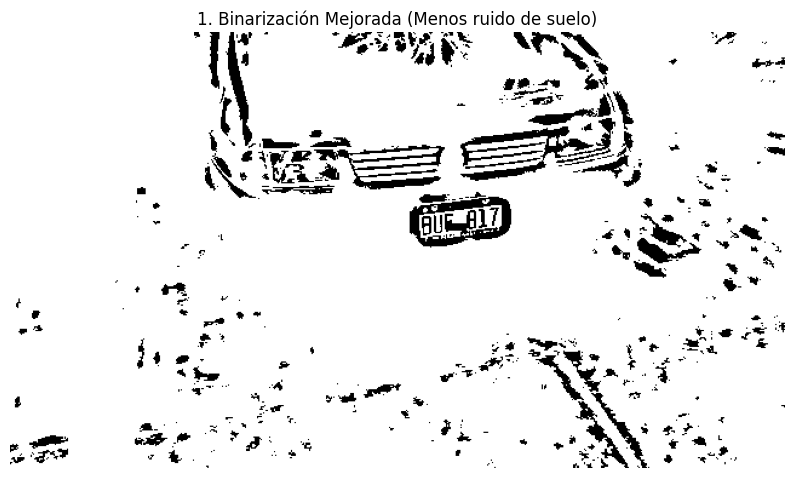

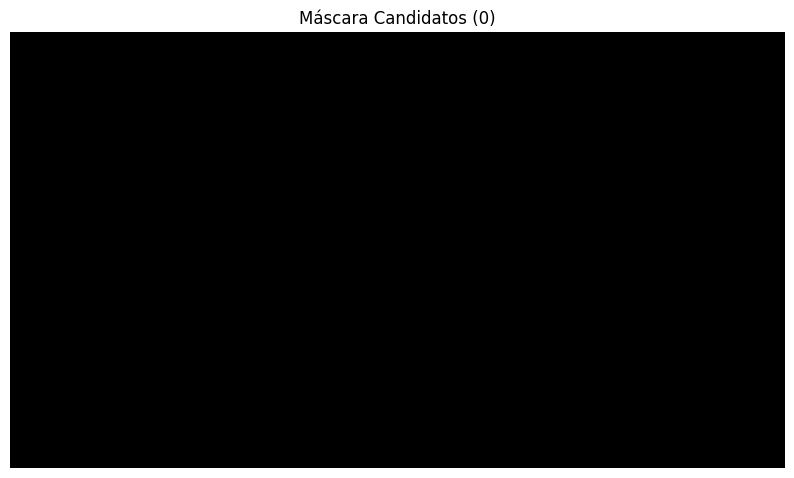

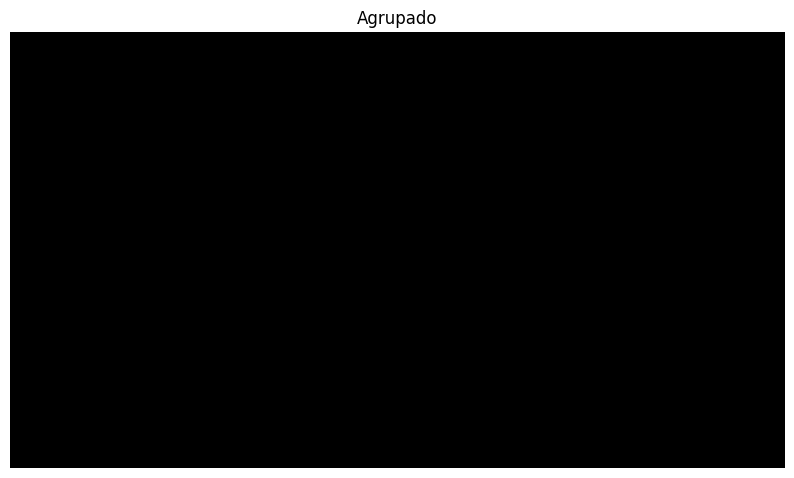

No se encontró ninguna patente candidata.


In [ ]:
def detectar_patente_mejorado(ruta_imagen):    
    img = cv2.imread(ruta_imagen)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h_img, w_img = gray.shape   

    kernel_hat = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel_hat)
    
    blur = cv2.bilateralFilter(blackhat, 11, 17, 17)

    thresh = cv2.adaptiveThreshold(blur, 255, 
                                   cv2.ADAPTIVE_THRESH_MEAN_C, 
                                   cv2.THRESH_BINARY, 19, 9)
    
    mostrar("1. Binarización Mejorada (Menos ruido de suelo)", thresh)

    # Filtrar componentes conectadas
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask_caracteres = np.zeros_like(gray)
    
    candidatos = 0
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(h) / w 
        area = w * h
        
        keep_aspect = 1.0 < aspect_ratio < 5.0 
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = float(area) / hull_area if hull_area > 0 else 0
        
        keep_size = (h_img * 0.02) < h < (h_img * 0.15) and area > 60
        
        if keep_aspect and keep_size and solidity > 0.35:
            cv2.drawContours(mask_caracteres, [cnt], -1, (255), thickness=cv2.FILLED)
            candidatos += 1
            
    mostrar(f"Máscara Candidatos ({candidatos})", mask_caracteres)

    #agrupacion
    kernel_fusion = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 3)) # Un poco más pequeño
    mask_agrupada = cv2.morphologyEx(mask_caracteres, cv2.MORPH_CLOSE, kernel_fusion)
    mask_agrupada = cv2.dilate(mask_agrupada, kernel_fusion, iterations=1)
    
    mostrar("Agrupado", mask_agrupada)
    
    contours_bloques, _ = cv2.findContours(mask_agrupada, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    mejor_rect = None
    max_score = 0
    
    for cnt in contours_bloques:
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(w) / h
        area = w * h
        
        if 1.0 < aspect_ratio < 3.0 and area > 800:
            if area > max_score:
                max_score = area
                mejor_rect = (x, y, w, h)

    if mejor_rect:
        px, py, pw, ph = mejor_rect
        pad = 5
        px = max(0, px - pad)
        py = max(0, py - pad)
        pw = min(w_img - px, pw + 2*pad)
        ph = min(h_img - py, ph + 2*pad)
        
        roi_patente = img[py:py+ph, px:px+pw]
        mostrar("Patente Detectada", roi_patente)
        
        img_final = img.copy()
        cv2.rectangle(img_final, (px, py), (px+pw, py+ph), (0, 255, 0), 3)
        mostrar("Resultado Final", img_final)
    else:
        print("No se encontró ninguna patente candidata.")

detectar_patente_mejorado('img/img01.png')

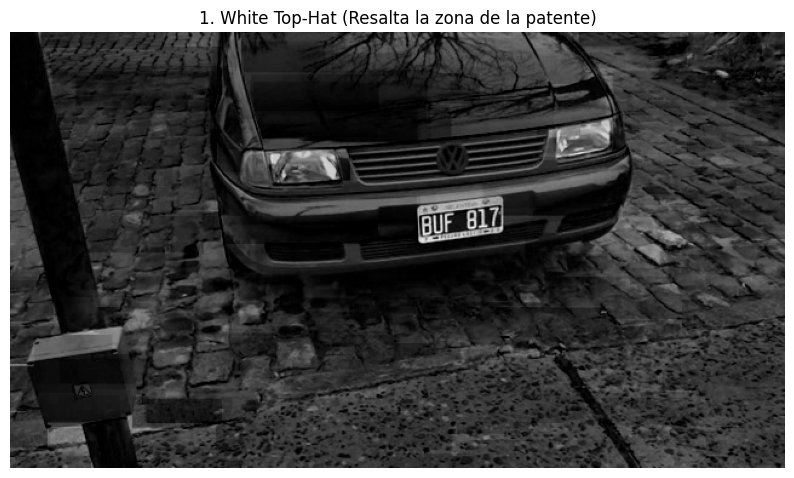

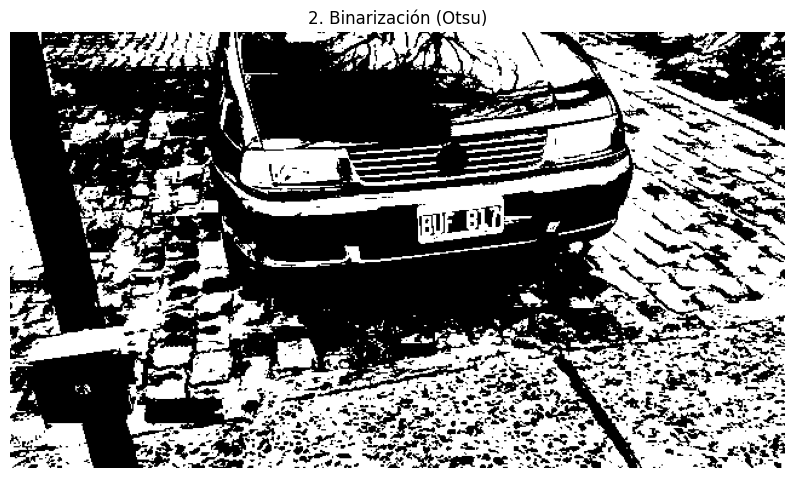

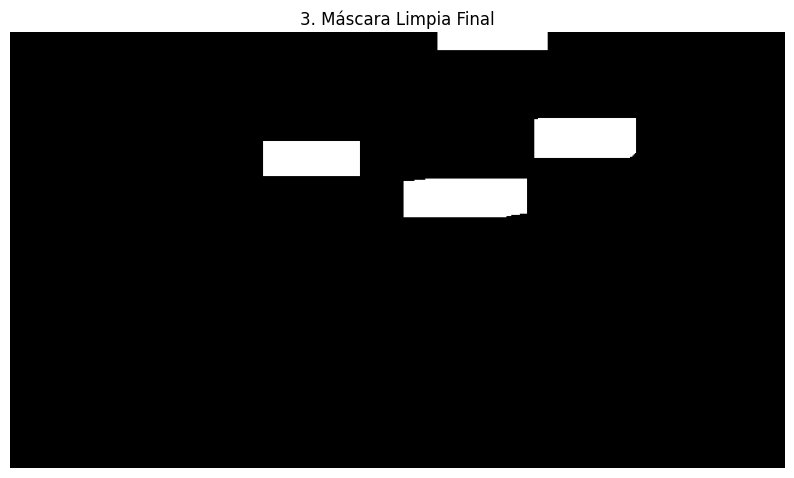

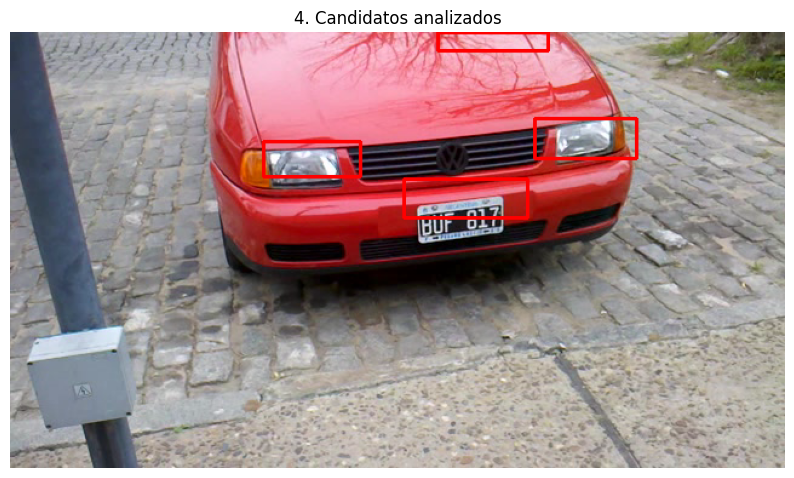

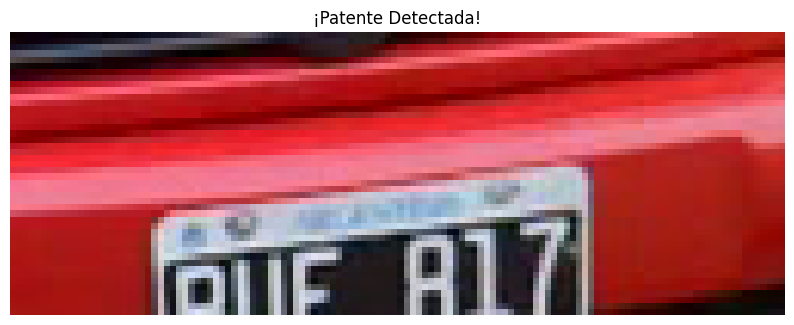

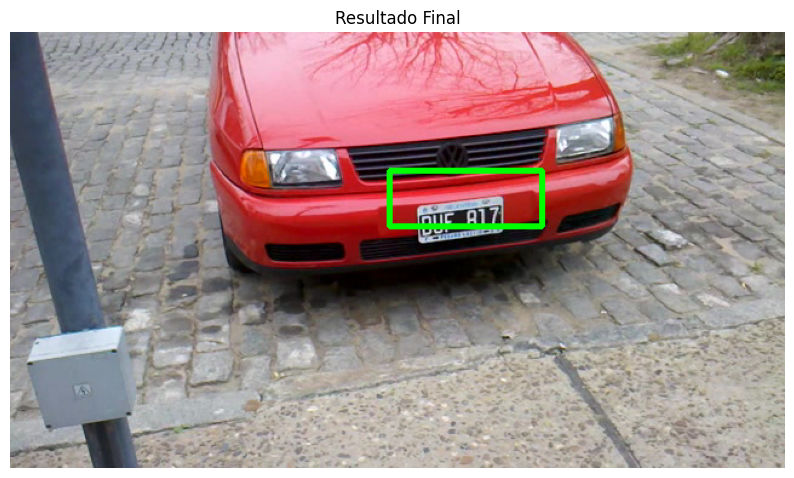

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def mostrar(titulo, imagen, cmap='gray'):
    plt.figure(figsize=(10, 6))
    plt.title(titulo)
    if len(imagen.shape) == 3:
        plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(imagen, cmap=cmap)
    plt.axis('off')
    plt.show()

def detectar_patente_tophat(ruta_imagen):    
    img = cv2.imread(ruta_imagen)
    if img is None:
        print("Error: No se pudo cargar la imagen.")
        return
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h_img, w_img = gray.shape
    
    # --- PASO 1: Transformación White Top-Hat ---
    # Definimos un kernel rectangular grande. Debe ser más grande que las piedras
    # pero aproximadamente del tamaño de la patente que esperamos.
    # Usamos un kernel ancho para favorecer formas horizontales.
    kernel_tophat = cv2.getStructuringElement(cv2.MORPH_RECT, (60, 20))
    
    # La operación Top-Hat extrae elementos brillantes pequeños (la patente)
    # del fondo oscuro, ignorando cambios de iluminación.
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel_tophat)
    
    mostrar("1. White Top-Hat (Resalta la zona de la patente)", tophat)

    # --- PASO 2: Binarización ---
    # Usamos Otsu para encontrar automáticamente el mejor umbral para separar
    # la zona brillante resaltada del fondo.
    _, thresh = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    
    mostrar("2. Binarización (Otsu)", thresh)

    # --- PASO 3: Limpieza Morfológica (Apertura) ---
    # Es probable que algunas piedras brillantes aún queden.
    # Usamos una "Apertura" (Morphological OPEN) con un kernel rectangular
    # para eliminar cualquier ruido que sea más pequeño que una patente.
    kernel_limpieza = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 15))
    mask_limpia = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_limpieza)
    
    # Una pequeña dilatación final para asegurar que el rectángulo cubra bien los bordes.
    mask_limpia = cv2.dilate(mask_limpia, kernel_limpieza, iterations=1)
    
    mostrar("3. Máscara Limpia Final", mask_limpia)

    # --- PASO 4: Encontrar Contornos del Bloque ---
    contours, _ = cv2.findContours(mask_limpia, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    mejor_rect = None
    max_area = 0
    
    img_debug = img.copy()

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(w) / h
        area = w * h
        
        # Dibujamos todos los candidatos para ver qué detecta
        cv2.rectangle(img_debug, (x, y), (x+w, y+h), (0, 0, 255), 2)
        
        # Filtros de geometría de patente (aprox 2:1 a 5:1 de ancho/alto)
        if 1.5 < aspect_ratio < 6.0 and area > 1500:
            if area > max_area:
                max_area = area
                mejor_rect = (x, y, w, h)
                
    mostrar("4. Candidatos analizados", img_debug)

    if mejor_rect:
        px, py, pw, ph = mejor_rect
        
        # Margen de seguridad (padding)
        pad_x = int(w_img * 0.02) 
        pad_y = int(h_img * 0.02)
        px = max(0, px - pad_x)
        py = max(0, py - pad_y)
        pw = min(w_img - px, pw + 2*pad_x)
        ph = min(h_img - py, ph + 2*pad_y)
        
        roi_patente = img[py:py+ph, px:px+pw]
        mostrar("¡Patente Detectada!", roi_patente)
        
        img_final = img.copy()
        cv2.rectangle(img_final, (px, py), (px+pw, py+ph), (0, 255, 0), 3)
        mostrar("Resultado Final", img_final)
    else:
        print("No se encontró ninguna región candidata plausible.")

# Ejecutar
detectar_patente_tophat('img/img01.png')